In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

import pickle
import joblib

from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

import missingno as msno

import warnings

In [3]:
warnings.filterwarnings('ignore')

In [4]:
# from azureml.core import Workspace, Dataset

# workspace = Workspace.from_config()

In [5]:
# from azureml.core import Dataset

# df_train = Dataset.Tabular.from_parquet_files((my_store, 'processed/df_train.parquet')).to_pandas_dataframe()
# df_valid = Dataset.Tabular.from_parquet_files((my_store, 'processed/df_valid.parquet')).to_pandas_dataframe()
# df_test  = Dataset.Tabular.from_parquet_files((my_store, 'processed/df_test.parquet')).to_pandas_dataframe()

In [6]:
df_train = pd.read_parquet('/content/drive/My Drive/Colab Notebooks/Dubai-Houses-MLOps/Data/raw-data/df_train.parquet')
df_valid = pd.read_parquet('/content/drive/My Drive/Colab Notebooks/Dubai-Houses-MLOps/Data/raw-data/df_valid.parquet')
df_test = pd.read_parquet('/content/drive/My Drive/Colab Notebooks/Dubai-Houses-MLOps/Data/raw-data/df_test.parquet')

In [ ]:
# from azureml.core import Dataset
# import pandas as pd

# train_file = Dataset.File.from_files((my_store, 'processed/df_train.parquet'))
# valid_file = Dataset.File.from_files((my_store, 'processed/df_valid.parquet'))
# test_file  = Dataset.File.from_files((my_store, 'processed/df_test.parquet'))

# df_train = pd.read_parquet(train_file.download()[0])
# df_valid = pd.read_parquet(valid_file.download()[0])
# df_test  = pd.read_parquet(test_file.download()[0])

In [7]:
pd.set_option('display.float_format', '{:.0f}'.format)

In [8]:
df_train.describe()

,price,beds,baths,average_rent,year_of_completion,total_parking_spaces,total_floors,total_building_area_sqft,elevators,Latitude,Longitude
count,24828,24828,24828,24828,24828,24828,24828,24828,24828,24817,24817
mean,3736695,2,3,92880,677,172,13,143,2,25,55
std,7820361,2,2,280615,953,353,20,248,4,0,1
min,0,0,0,0,0,0,0,0,0,15,43
25%,1100000,1,2,0,0,0,0,0,0,25,55
50%,2000000,2,3,0,0,0,0,0,0,25,55
75%,3582000,3,4,123371,2011,198,22,211,4,25,55
max,482500000,11,11,28079524,2024,2929,89,997,42,26,56


In [9]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24828 entries, 0 to 24827
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   price                     24828 non-null  int64  
 1   price_category            24828 non-null  object 
 2   type                      24828 non-null  object 
 3   beds                      24828 non-null  int64  
 4   baths                     24828 non-null  int64  
 5   address                   24828 non-null  object 
 6   furnishing                24828 non-null  object 
 7   completion_status         24828 non-null  object 
 8   post_date                 24828 non-null  object 
 9   average_rent              24828 non-null  int64  
 10  building_name             24828 non-null  object 
 11  year_of_completion        24828 non-null  int64  
 12  total_parking_spaces      24828 non-null  int64  
 13  total_floors              24828 non-null  int64  
 14  total_

## Transformation of the Y variable

In [10]:
import matplotlib.ticker as mtick

from scipy.stats import boxcox, yeojohnson # for power transformations

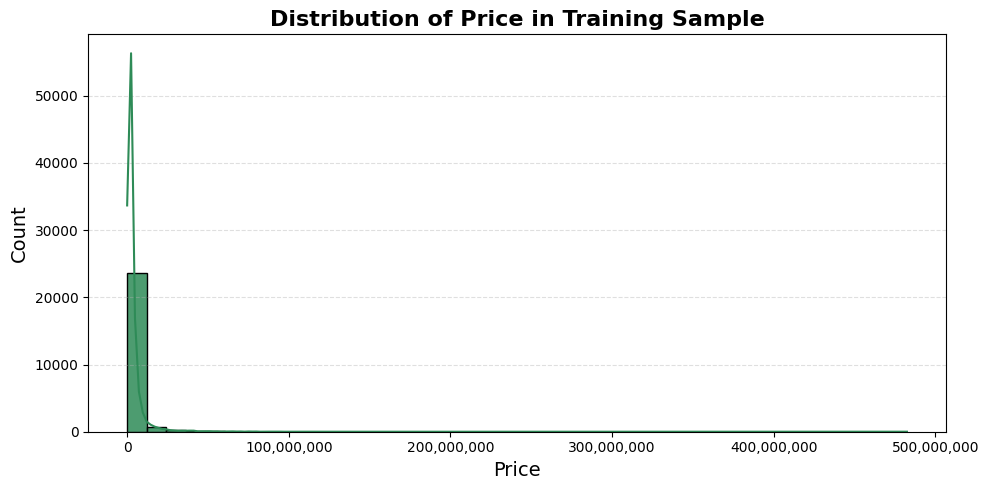

In [ ]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df_train['price'],
    kde=True,
    bins=40,
    color='seagreen',
    edgecolor='black',
    alpha=0.85
)

plt.title('Distribution of Price in Training Sample', fontsize=16, fontweight='bold')
plt.xlabel('Price', fontsize=14)
plt.ylabel('Count', fontsize=14)

plt.gca().xaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [23]:
# If True → use log1p; if False → log is fine.
(df_train['price'] <= 0).any()

np.True_

In [24]:
# y - logged
df_train_y_log = np.log(df_train['price'])

In [25]:
# y - logged + 1
df_train_y_log_p1 = np.log(df_train['price'] + 1)

In [26]:
# if any values ≤ 0, Box-Cox cannot be used directly.
(df_train['price'] <= 0).any()

np.True_

In [27]:
# y - boxcox
df_train_y_boxcox, fitted_lambda = boxcox(df_train['price'] + 1)

print(fitted_lambda)

# adding +1 makes all values positive, so Box-Cox can be applied.

0.04669015762537189


In [28]:
# y - yeojohnson
df_train_y_yeojohnson, fitted_lambda2 = yeojohnson(df_train['price'])

print(fitted_lambda2)

0.046690186097626415


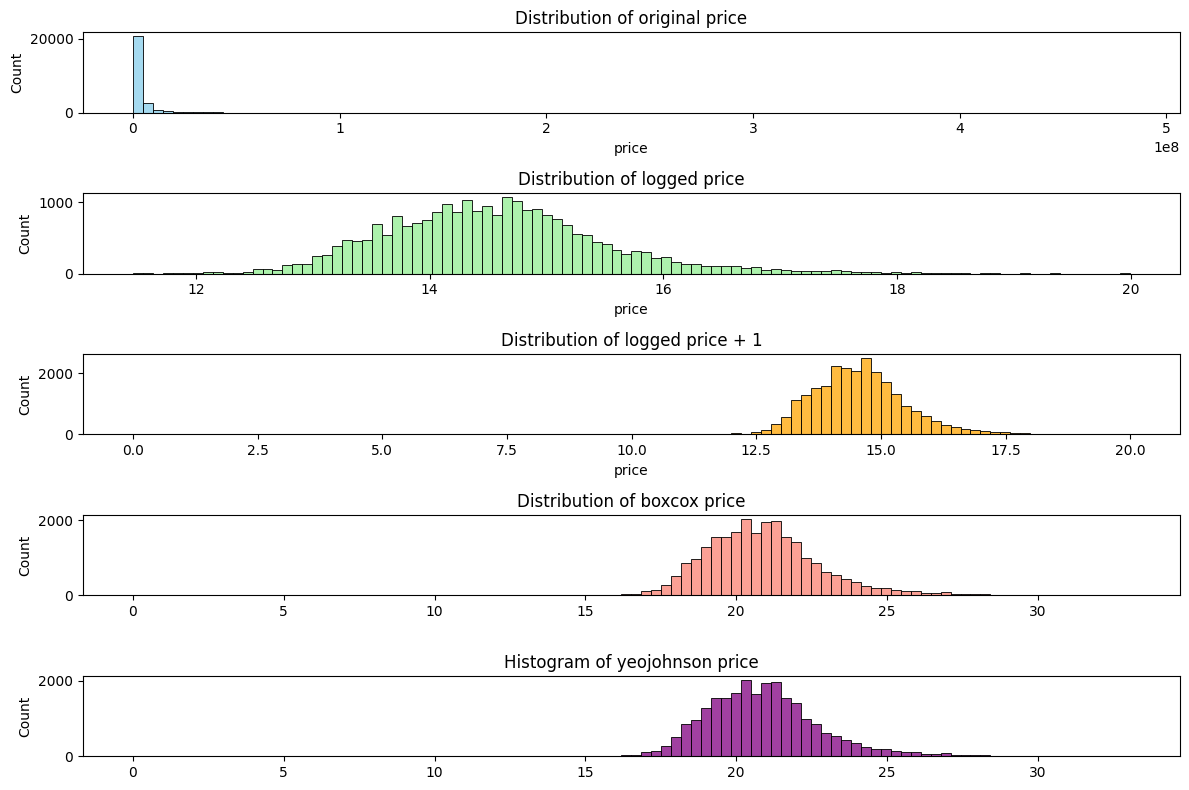

In [ ]:
fig, axs = plt.subplots(5, 1, figsize = (12, 8)) # 4 rows, 1 column

sns.histplot(
    df_train['price'],
    bins = 100,
    ax = axs[0],
    color = 'skyblue'
)
axs[0].set_title('Distribution of original price')

sns.histplot(
    df_train_y_log,
    bins = 100,
    ax = axs[1],
    color = 'lightgreen'
)
axs[1].set_title('Distribution of logged price')

sns.histplot(
    df_train_y_log_p1,
    bins = 100,
    ax = axs[2],
    color = 'orange'
)
axs[2].set_title('Distribution of logged price + 1')

sns.histplot(
    df_train_y_boxcox,
    bins = 100,
    ax = axs[3],
    color = 'salmon'
)
axs[3].set_title('Distribution of boxcox price')

sns.histplot(
    df_train_y_yeojohnson,
    bins = 100,
    ax = axs[4],
    color = 'purple'
)
axs[4].set_title('Histogram of yeojohnson price')

plt.tight_layout()
plt.show()

In [29]:
df_train['price_y'] = yeojohnson(df_train['price'], lmbda=fitted_lambda2)
df_valid['price_y'] = yeojohnson(df_valid['price'], lmbda=fitted_lambda2)
df_test['price_y'] = yeojohnson(df_test['price'], lmbda=fitted_lambda2)

In [ ]:
# from scipy.stats import yeojohnson, yeojohnson_normmax, yeojohnson_inverse

# # inverse transform
# df_train['price_inv'] = yeojohnson_inverse(df_train['price_y'], lmbda=fitted_lambda2)
# df_valid['price_inv'] = yeojohnson_inverse(df_valid['price_y'], lmbda=fitted_lambda2)
# df_test['price_inv']  = yeojohnson_inverse(df_test['price_y'],  lmbda=fitted_lambda2)


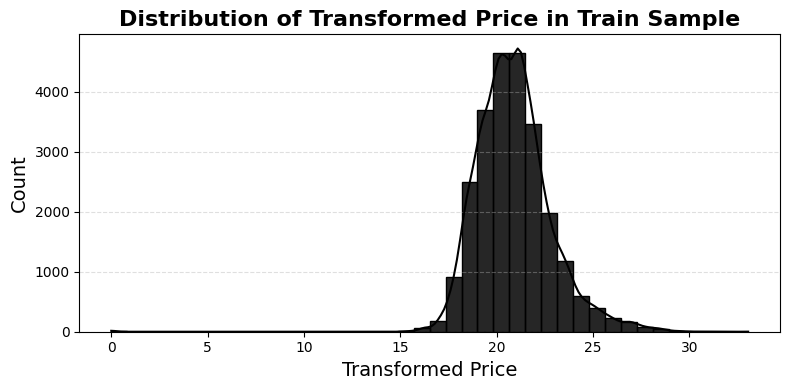

In [ ]:
plt.figure(figsize=(8, 4))

sns.histplot(
    df_train['price_y'],
    kde=True,
    bins=40,
    color='black',
    edgecolor='black',
    alpha=0.85
)

plt.title('Distribution of Transformed Price in Train Sample',
          fontsize=16, fontweight='bold')
plt.xlabel('Transformed Price', fontsize=14)
plt.ylabel('Count', fontsize=14)

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

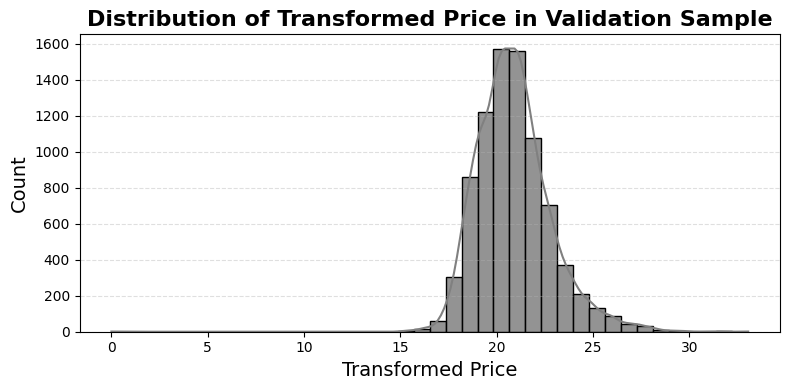

In [ ]:
plt.figure(figsize=(8, 4))

sns.histplot(
    df_valid['price_y'],
    kde=True,
    bins=40,
    color='grey',
    edgecolor='black',
    alpha=0.85
)

plt.title('Distribution of Transformed Price in Validation Sample',
          fontsize=16, fontweight='bold')
plt.xlabel('Transformed Price', fontsize=14)
plt.ylabel('Count', fontsize=14)

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

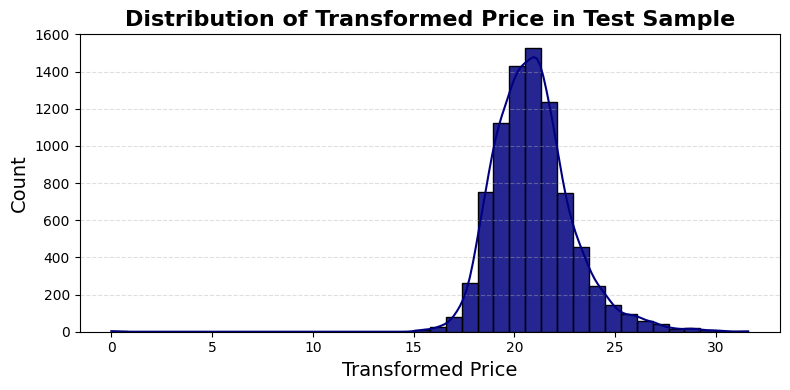

In [ ]:
plt.figure(figsize=(8, 4))

sns.histplot(
    df_test['price_y'],
    kde=True,
    bins=40,
    color='navy',
    edgecolor='black',
    alpha=0.85
)

plt.title('Distribution of Transformed Price in Test Sample',
          fontsize=16, fontweight='bold')
plt.xlabel('Transformed Price', fontsize=14)
plt.ylabel('Count', fontsize=14)

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [ ]:
def near_zero_var(df, freq_cut=95/5, unique_cut=10):
    results = []
    for col in df.columns:
        counts = df[col].value_counts()

        # calculate freq_ratio
        if len(counts) > 1:
            freq_ratio = counts.iloc[0] / counts.iloc[1]
        else:
            freq_ratio = float('inf')  # or np.inf

        # calculate unique_ratio
        unique_ratio = len(counts) / len(df) * 100

        # determine binary indicators
        high_freq_ratio = int(freq_ratio > freq_cut)
        low_unique_ratio = int(unique_ratio < unique_cut)

        # append results
        results.append({
            'variable': col,
            'freq_ratio': freq_ratio,
            'unique_ratio': unique_ratio,
            'high_freq_ratio': high_freq_ratio,
            'low_unique_ratio': low_unique_ratio
        })

    results_df = pd.DataFrame(results)
    # sort by high_freq_ratio (descending) and low_unique_ratio (ascending)
    results_df = results_df.sort_values(
        by=['freq_ratio', 'unique_ratio'], ascending=[False, True])

    return results_df

In [ ]:
unique_cut = len(df_train) * 0.1

df_train_nzv = near_zero_var(df_train, freq_cut=90/10, unique_cut=unique_cut)

In [ ]:
df_train_nzv

,variable,freq_ratio,unique_ratio,high_freq_ratio,low_unique_ratio
18,country,inf,0,1,1
21,purpose,inf,0,1,1
9,average_rent,245,38,1,1
12,total_parking_spaces,185,2,1,1
10,building_name,153,6,1,1
13,total_floors,35,0,1,1
15,elevators,15,0,1,1
11,year_of_completion,14,0,1,1
14,total_building_area_sqft,7,2,0,1
17,city,5,0,0,1


In [ ]:
df_train_nzv[(df_train_nzv['low_unique_ratio'] == 1) & (df_train_nzv['high_freq_ratio'] == 1)]

,variable,freq_ratio,unique_ratio,high_freq_ratio,low_unique_ratio
18,country,inf,0,1,1
21,purpose,inf,0,1,1
9,average_rent,245,38,1,1
12,total_parking_spaces,185,2,1,1
10,building_name,153,6,1,1
13,total_floors,35,0,1,1
15,elevators,15,0,1,1
11,year_of_completion,14,0,1,1


In [ ]:
nzv_variables = ['country', 'purpose', 'average_rent', 'total_parking_spaces',
                 'building_name', 'total_floors', 'elevators', 'year_of_completion']

for var in nzv_variables:
    print(f'Frequency counts for {var}')
    print(df_train[var].value_counts(normalize=True))
    print('-----------------------------------------')

Frequency counts for country
UAE   1
Name: country, dtype: float64
-----------------------------------------
Frequency counts for purpose
For Sale   1
Name: purpose, dtype: float64
-----------------------------------------
Frequency counts for average_rent
0        1 
90630    0 
58324    0 
100511   0 
88762    0 
         ..
213226   0 
237930   0 
368755   0 
476894   0 
161559   0 
Name: average_rent, Length: 9373, dtype: float64
-----------------------------------------
Frequency counts for total_parking_spaces
0      1 
1295   0 
1959   0 
451    0 
1696   0 
       ..
557    0 
30     0 
524    0 
609    0 
423    0 
Name: total_parking_spaces, Length: 499, dtype: float64
-----------------------------------------
Frequency counts for building_name
Unknown                                 1 
AYKON CITY-TOWER B                      0 
AYKON CITY (2) -TOWER C                 0 
Forte T1                                0 
SEVEN HOTEL & APARTMENTS THE PALM - B   0 
                    

In [ ]:
df_train['elevators'].value_counts()

0     17007
4      1126
3       918
6       875
5       837
7       800
8       603
2       580
9       461
11      296
10      285
13      231
19      145
14      138
12      118
27       78
15       75
20       42
17       41
26       31
16       30
34       27
28       24
18       20
21       12
42       11
23       11
30        2
24        2
31        2
Name: elevators, dtype: int64

In [ ]:
df_train['total_floors'].value_counts()

0     14093
6       404
8       355
7       342
5       325
      ...  
3        16
70       10
71        9
63        6
2         2
Name: total_floors, Length: 82, dtype: int64

In [11]:
df_train_copy = df_train.copy()
df_valid_copy = df_valid.copy()
df_test_copy = df_test.copy()

In [ ]:
# df_train = df_train_copy.copy()
# df_valid = df_valid_copy.copy()
# df_test = df_test_copy.copy()

In [ ]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24828 entries, 0 to 24827
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   price                     24828 non-null  int64  
 1   price_category            24828 non-null  object 
 2   type                      24828 non-null  object 
 3   beds                      24828 non-null  int64  
 4   baths                     24828 non-null  int64  
 5   address                   24828 non-null  object 
 6   furnishing                24828 non-null  object 
 7   completion_status         24828 non-null  object 
 8   post_date                 24828 non-null  object 
 9   average_rent              24828 non-null  int64  
 10  building_name             24828 non-null  object 
 11  year_of_completion        24828 non-null  int64  
 12  total_parking_spaces      24828 non-null  int64  
 13  total_floors              24828 non-null  int64  
 14  total_

In [12]:
# fix datatime format

# train sample
df_train['post_date'] = (
    df_train['post_date']
    .astype(str)
    .str.strip()
    .str.replace(r'[^\d\-]', '', regex=True)   # keep only digits and hyphens
)

df_train['post_date'] = pd.to_datetime(df_train['post_date'], errors='coerce')

# validation sample
df_valid['post_date'] = (
    df_valid['post_date']
    .astype(str)
    .str.strip()
    .str.replace(r'[^\d\-]', '', regex=True)   # keep only digits and hyphens
)

df_valid['post_date'] = pd.to_datetime(df_valid['post_date'], errors='coerce')

# test sample
df_test['post_date'] = (
    df_test['post_date']
    .astype(str)
    .str.strip()
    .str.replace(r'[^\d\-]', '', regex=True)   # keep only digits and hyphens
)

df_test['post_date'] = pd.to_datetime(df_test['post_date'], errors='coerce')

In [13]:
# 2. categorical columns change to "category" data type
categorical_cols = [
    'price_category', 'type', 'address', 'furnishing',
    'completion_status', 'building_name', 'area_name',
    'city', 'country', 'purpose'
]

# train sample
df_train[categorical_cols] = df_train[categorical_cols].astype('category')
# validation sample
df_valid[categorical_cols] = df_valid[categorical_cols].astype('category')
# test sample
df_test[categorical_cols] = df_test[categorical_cols].astype('category')

In [14]:
# 3. Convert integer-like columns
int_cols = [
    'beds', 'baths', 'average_rent', 'year_of_completion',
    'total_parking_spaces', 'total_floors', 'total_building_area_sqft',
    'elevators'
]

# train sample
df_train[int_cols] = df_train[int_cols].astype('int64')
# validation sample
df_valid[int_cols] = df_valid[int_cols].astype('int64')
# test sample
df_test[int_cols] = df_test[int_cols].astype('int64')

In [15]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24828 entries, 0 to 24827
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   price                     24828 non-null  int64         
 1   price_category            24828 non-null  category      
 2   type                      24828 non-null  category      
 3   beds                      24828 non-null  int64         
 4   baths                     24828 non-null  int64         
 5   address                   24828 non-null  category      
 6   furnishing                24828 non-null  category      
 7   completion_status         24828 non-null  category      
 8   post_date                 24828 non-null  datetime64[ns]
 9   average_rent              24828 non-null  int64         
 10  building_name             24828 non-null  category      
 11  year_of_completion        24828 non-null  int64         
 12  total_parking_spac

In [16]:
df_valid.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8276 entries, 0 to 8275
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   price                     8276 non-null   int64         
 1   price_category            8276 non-null   category      
 2   type                      8276 non-null   category      
 3   beds                      8276 non-null   int64         
 4   baths                     8276 non-null   int64         
 5   address                   8276 non-null   category      
 6   furnishing                8276 non-null   category      
 7   completion_status         8276 non-null   category      
 8   post_date                 8276 non-null   datetime64[ns]
 9   average_rent              8276 non-null   int64         
 10  building_name             8276 non-null   category      
 11  year_of_completion        8276 non-null   int64         
 12  total_parking_spaces

In [ ]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8277 entries, 0 to 8276
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   price                     8277 non-null   int64         
 1   price_category            8277 non-null   category      
 2   type                      8277 non-null   category      
 3   beds                      8277 non-null   int64         
 4   baths                     8277 non-null   int64         
 5   address                   8277 non-null   category      
 6   furnishing                8277 non-null   category      
 7   completion_status         8277 non-null   category      
 8   post_date                 8277 non-null   datetime64[ns]
 9   average_rent              8277 non-null   int64         
 10  building_name             8277 non-null   category      
 11  year_of_completion        8277 non-null   int64         
 12  total_parking_spaces

In [ ]:
df_train['purpose'].value_counts()

# you can delete this too as it has only one level

For Sale    24828
Name: purpose, dtype: int64

In [17]:
cols_to_drop = [
    'address',
    'building_name',
    'country',
    'price_category',   # if predicting price
    'purpose'
]

In [18]:
# deleting irrelevant columns

# train sample
df_train = df_train.drop(columns=cols_to_drop)
# validation sample
df_valid = df_valid.drop(columns=cols_to_drop)
# test sample
df_test = df_test.drop(columns=cols_to_drop)

In [19]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24828 entries, 0 to 24827
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   price                     24828 non-null  int64         
 1   type                      24828 non-null  category      
 2   beds                      24828 non-null  int64         
 3   baths                     24828 non-null  int64         
 4   furnishing                24828 non-null  category      
 5   completion_status         24828 non-null  category      
 6   post_date                 24828 non-null  datetime64[ns]
 7   average_rent              24828 non-null  int64         
 8   year_of_completion        24828 non-null  int64         
 9   total_parking_spaces      24828 non-null  int64         
 10  total_floors              24828 non-null  int64         
 11  total_building_area_sqft  24828 non-null  int64         
 12  elevators         

In [ ]:
df_train.head()

,price,type,beds,baths,furnishing,completion_status,post_date,average_rent,year_of_completion,total_parking_spaces,total_floors,total_building_area_sqft,elevators,area_name,city,Latitude,Longitude,price_y
0,23000000,Villa,4,5,Unfurnished,Ready,2023-12-05,284778,0,0,0,0,0,Umm Suqeim,Dubai,25,55,26
1,4794000,Townhouse,5,6,Unfurnished,Off-Plan,2024-04-19,0,0,0,0,0,0,Sharjah Garden City,Sharjah,25,56,23
2,1650000,Apartment,3,4,Unfurnished,Ready,2024-02-24,129166,0,0,0,0,0,Masdar City,Abu Dhabi,24,55,20
3,3300000,Townhouse,4,5,Unfurnished,Ready,2024-03-01,223020,0,0,0,0,0,Reem,Dubai,25,55,22
4,2350000,Apartment,2,3,Furnished,Ready,2023-11-22,158650,2007,0,53,454,0,Jumeirah Beach Residence (JBR),Dubai,25,55,21


In [ ]:
# handling missing values

df_train.isnull().sum()

price                        0
type                         0
beds                         0
baths                        0
furnishing                   0
completion_status            0
post_date                    0
average_rent                 0
year_of_completion           0
total_parking_spaces         0
total_floors                 0
total_building_area_sqft     0
elevators                    0
area_name                    0
city                         0
Latitude                    11
Longitude                   11
price_y                      0
dtype: int64

In [20]:
# train sample
# Median values
lat_median = df_train['Latitude'].median()
lon_median = df_train['Longitude'].median()

# Impute missing values
df_train['Latitude'] = df_train['Latitude'].fillna(lat_median)
df_train['Longitude'] = df_train['Longitude'].fillna(lon_median)

# Check missing values after imputation
print("\nMissing after:")
print(df_train[['Latitude', 'Longitude']].isna().sum())

# validation sample
# Median values
lat_median = df_valid['Latitude'].median()
lon_median = df_valid['Longitude'].median()

# Impute missing values
df_valid['Latitude'] = df_valid['Latitude'].fillna(lat_median)
df_valid['Longitude'] = df_valid['Longitude'].fillna(lon_median)

# Check missing values after imputation
print("\nMissing after:")
print(df_valid[['Latitude', 'Longitude']].isna().sum())

# test sample
# Median values
lat_median = df_test['Latitude'].median()
lon_median = df_test['Longitude'].median()

# Impute missing values
df_test['Latitude'] = df_test['Latitude'].fillna(lat_median)
df_test['Longitude'] = df_test['Longitude'].fillna(lon_median)

# Check missing values after imputation
print("\nMissing after:")
print(df_test[['Latitude', 'Longitude']].isna().sum())


Missing after:
Latitude     0
Longitude    0
dtype: int64

Missing after:
Latitude     0
Longitude    0
dtype: int64

Missing after:
Latitude     0
Longitude    0
dtype: int64


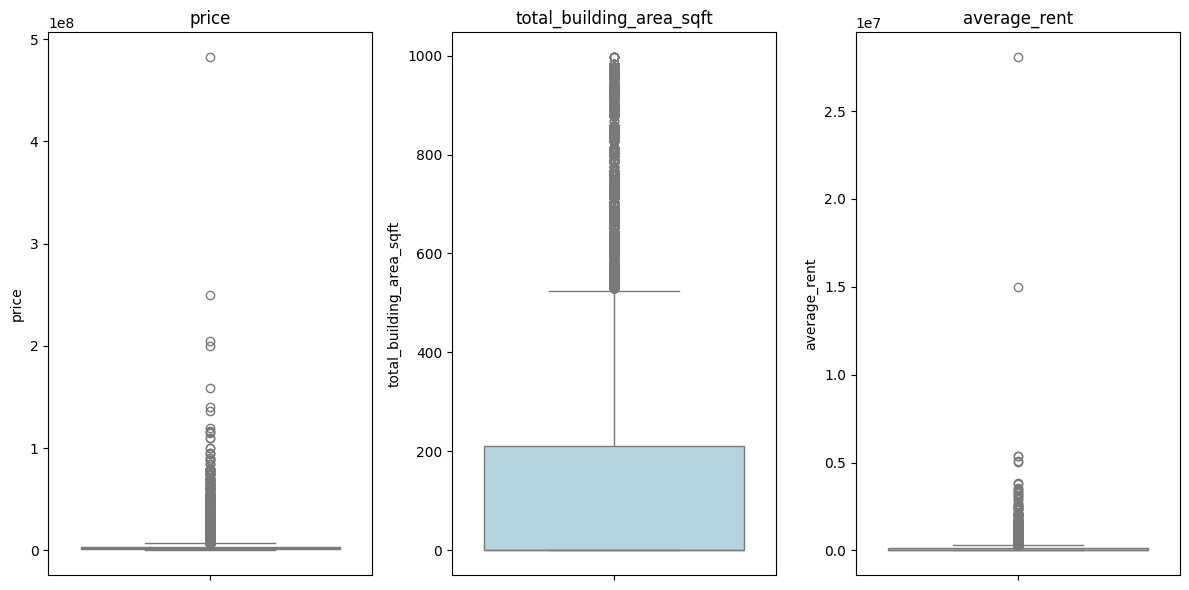

In [21]:

num_cols = ['price', 'total_building_area_sqft', 'average_rent']

plt.figure(figsize=(12, 6))
for i, col in enumerate(num_cols, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=df_train[col], color='lightblue')
    plt.title(col)
plt.tight_layout()
plt.show()

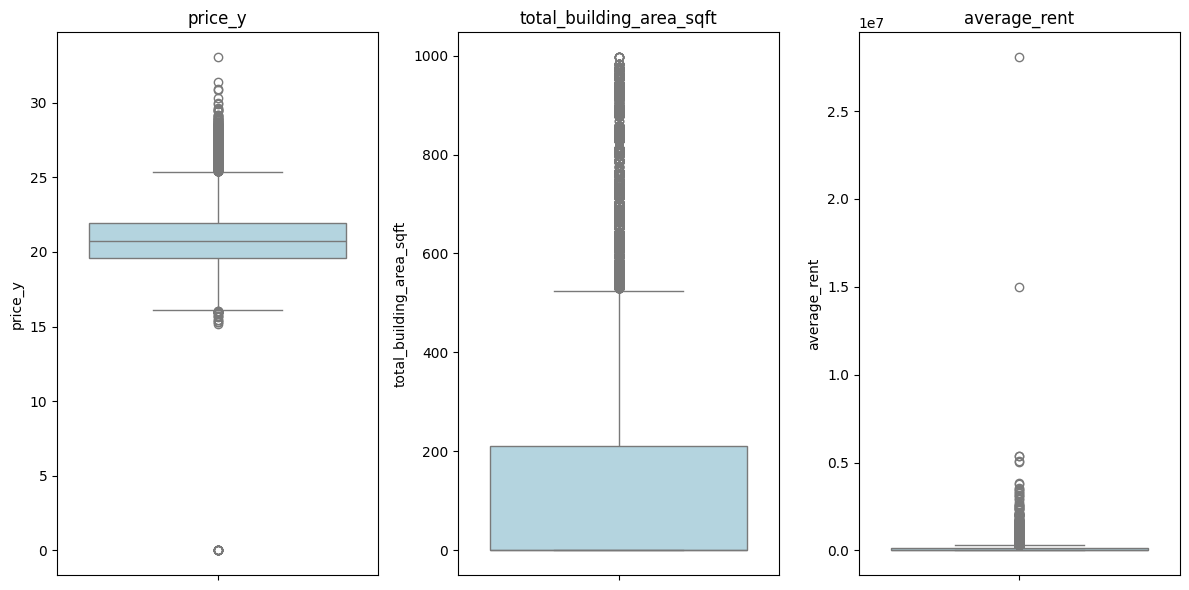

In [30]:
# transformed price to yeojohnson
num_cols = ['price_y', 'total_building_area_sqft', 'average_rent']

plt.figure(figsize=(12, 6))
for i, col in enumerate(num_cols, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=df_train[col], color='lightblue')
    plt.title(col)
plt.tight_layout()
plt.show()

In [31]:
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return lower, upper

In [32]:
# check thresholds
for col in num_cols:
    low, high = detect_outliers_iqr(df_train, col)
    print(f"{col}: lower={low:.2f}, upper={high:.2f}")


price_y: lower=16.10, upper=25.40
total_building_area_sqft: lower=-316.50, upper=527.50
average_rent: lower=-185056.12, upper=308426.88


In [33]:
# winsorizing
from scipy.stats.mstats import winsorize
import numpy as np

def winsorize_series(s, lower=0.01, upper=0.01):
    """Winsorize a pandas Series on raw values only."""
    arr = winsorize(s, limits=(lower, upper))
    return pd.Series(arr, index=s.index)

In [34]:
# Optional: winsorize raw price
df_train['price_w'] = winsorize_series(df_train['price'], lower=0.01, upper=0.01)

# Re-transform after winsorization (if you want a new transformed version)
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method='yeo-johnson')
df_train['price_y_new'] = pt.fit_transform(df_train[['price_w']])

# ------------------------------------------------------------

# 1. Winsorize raw price (optional)
df_train['price_w'] = winsorize_series(
    df_train['price'],
    lower=0.01,
    upper=0.01
)
# 2. Log1p transform AFTER winsorization
df_train['price_log1p'] = np.log1p(df_train['price_w'])

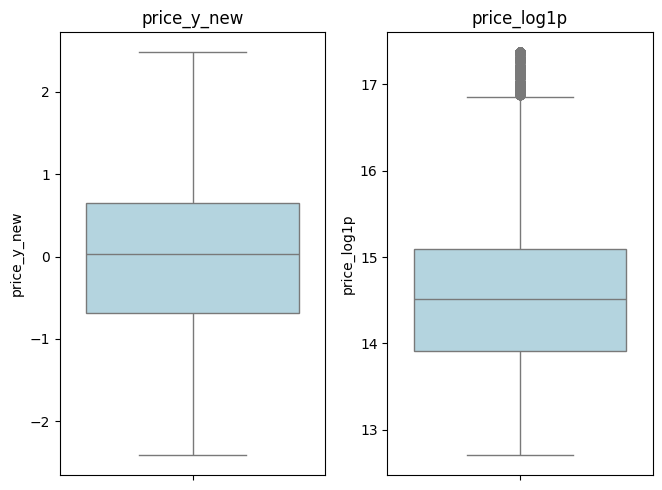

In [35]:
# transformed price to yeojohnson
num_cols = ['price_y_new', 'price_log1p']

plt.figure(figsize=(10, 5))
for i, col in enumerate(num_cols, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=df_train[col], color='lightblue')
    plt.title(col)
plt.tight_layout()
plt.show()

In [ ]:
# # we will go for log1p

# log1p is interpretable

# It stabilizes variance without over‑smoothing

# Winsorizing raw values prevents extreme leverage

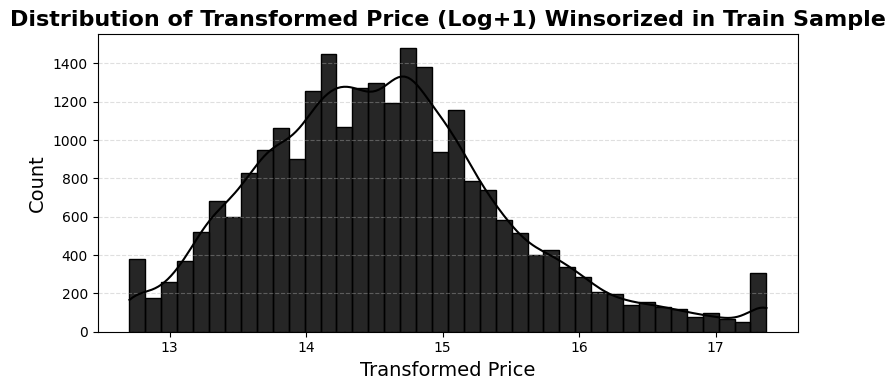

In [ ]:
plt.figure(figsize=(8, 4))

sns.histplot(
    df_train['price_log1p'],
    kde=True,
    bins=40,
    color='black',
    edgecolor='black',
    alpha=0.85
)

plt.title('Distribution of Transformed Price (Log+1) Winsorized in Train Sample',
          fontsize=16, fontweight='bold')
plt.xlabel('Transformed Price', fontsize=14)
plt.ylabel('Count', fontsize=14)

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

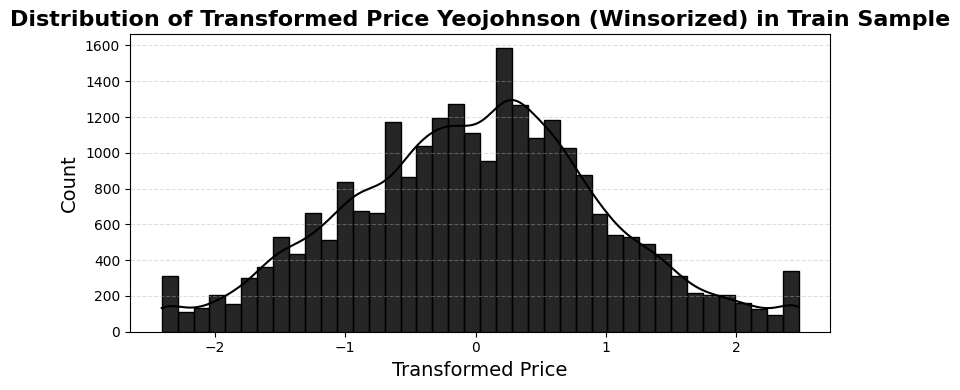

In [ ]:
plt.figure(figsize=(8, 4))

sns.histplot(
    df_train['price_y_new'],
    kde=True,
    bins=40,
    color='black',
    edgecolor='black',
    alpha=0.85
)

plt.title('Distribution of Transformed Price Yeojohnson (Winsorized) in Train Sample',
          fontsize=16, fontweight='bold')
plt.xlabel('Transformed Price', fontsize=14)
plt.ylabel('Count', fontsize=14)

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [ ]:
# Yeo–Johnson (winsorized) → extremely normalized, centered at 0, almost too Gaussian

# log1p (winsorized) → bell‑shaped but still preserves real economic variation

In [36]:
# Winsorize raw sqft
df_train['total_building_area_sqft_w'] = winsorize_series(
    df_train['total_building_area_sqft'],
    lower=0.01,
    upper=0.01
)

# Log transform (best for real estate)
df_train['total_building_area_sqft_log'] = np.log1p(df_train['total_building_area_sqft_w'])


In [37]:
df_train['average_rent'].sort_values(ascending=False).head(10)

,average_rent
24075,28079524
23989,14988793
9664,5402151
6044,5402151
8597,5090127
5757,5047360
21330,3830109
2168,3802408
22126,3573688
8977,3483691


In [38]:
# Remove impossible rent values
df_train = df_train[df_train['average_rent'] <= 700_000]

# # or
# cutoff = df_train['average_rent'].quantile(0.995)
# df_train = df_train[df_train['average_rent'] <= cutoff]

In [39]:
df_train['average_rent_w'] = winsorize_series(
    df_train['average_rent'],
    lower=0.01,
    upper=0.01
)

df_train['average_rent_log'] = np.log1p(df_train['average_rent_w'])

### Results:
Winsorizing + Log + 1

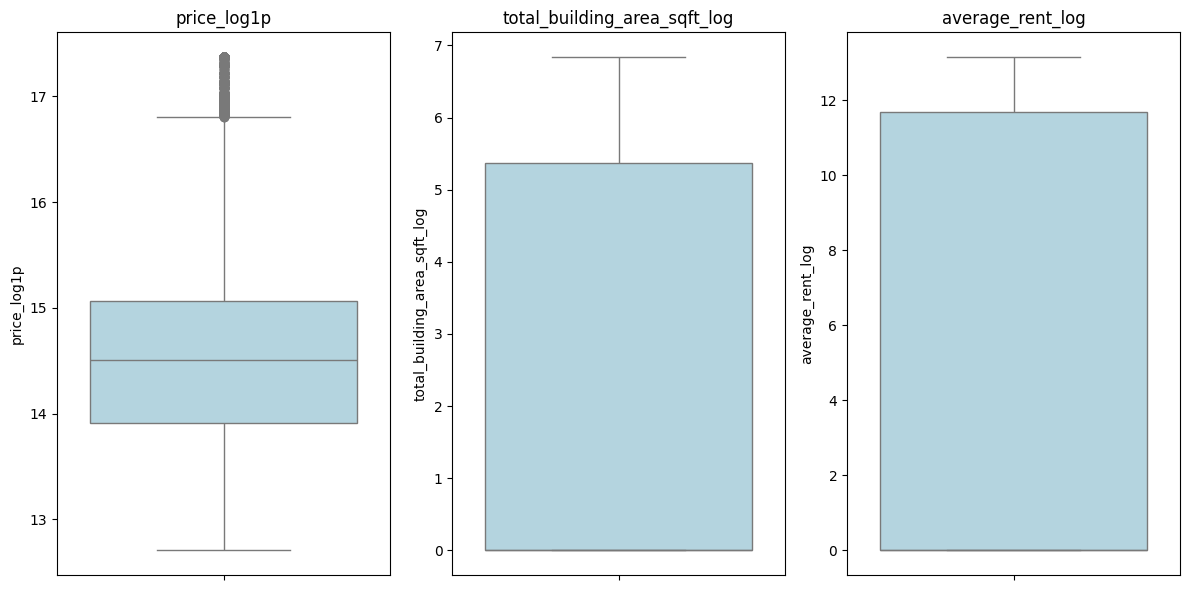

In [40]:
# transformed price to yeojohnson
num_cols = ['price_log1p', 'total_building_area_sqft_log', 'average_rent_log']

plt.figure(figsize=(12, 6))
for i, col in enumerate(num_cols, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=df_train[col], color='lightblue')
    plt.title(col)
plt.tight_layout()
plt.show()

In [ ]:
# apply the same in valid and test samples

In [41]:
# validation sample

# 1. Winsorize raw price (optional)
df_valid['price_w'] = winsorize_series(
    df_valid['price'],
    lower=0.01,
    upper=0.01
)
# 2. Log1p transform AFTER winsorization
df_valid['price_log1p'] = np.log1p(df_valid['price_w'])


# test sample

# 1. Winsorize raw price (optional)
df_test['price_w'] = winsorize_series(
    df_test['price'],
    lower=0.01,
    upper=0.01
)
# 2. Log1p transform AFTER winsorization
df_test['price_log1p'] = np.log1p(df_test['price_w'])

In [42]:
# validation sample

# Winsorize raw sqft
df_valid['total_building_area_sqft_w'] = winsorize_series(
    df_valid['total_building_area_sqft'],
    lower=0.01,
    upper=0.01
)

# Log transform (best for real estate)
df_valid['total_building_area_sqft_log'] = np.log1p(df_valid['total_building_area_sqft_w'])


# test sample
# Winsorize raw sqft
df_test['total_building_area_sqft_w'] = winsorize_series(
    df_test['total_building_area_sqft'],
    lower=0.01,
    upper=0.01
)

# Log transform (best for real estate)
df_test['total_building_area_sqft_log'] = np.log1p(df_test['total_building_area_sqft_w'])

In [43]:
# validation sample
df_valid['average_rent_w'] = winsorize_series(
    df_valid['average_rent'],
    lower=0.01,
    upper=0.01
)

df_valid['average_rent_log'] = np.log1p(df_valid['average_rent_w'])

# test sample
df_test['average_rent_w'] = winsorize_series(
    df_test['average_rent'],
    lower=0.01,
    upper=0.01
)

df_test['average_rent_log'] = np.log1p(df_test['average_rent_w'])

In [ ]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 24537 entries, 0 to 24827
Data columns (total 25 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   price                         24537 non-null  int64         
 1   type                          24537 non-null  category      
 2   beds                          24537 non-null  int64         
 3   baths                         24537 non-null  int64         
 4   furnishing                    24537 non-null  category      
 5   completion_status             24537 non-null  category      
 6   post_date                     24537 non-null  datetime64[ns]
 7   average_rent                  24537 non-null  int64         
 8   year_of_completion            24537 non-null  int64         
 9   total_parking_spaces          24537 non-null  int64         
 10  total_floors                  24537 non-null  int64         
 11  total_building_area_sqft    

In [45]:
cols_to_drop = [
    'price_w',
    'price_y_new',
    'price_y',
    'total_building_area_sqft',
    'total_building_area_sqft_w',
    'average_rent',
    'average_rent_w'
]

df_train = df_train.drop(columns=cols_to_drop)

In [44]:
cols_to_drop = [
    'price_w',
    'price_y',
    'total_building_area_sqft',
    'total_building_area_sqft_w',
    'average_rent',
    'average_rent_w'
]


df_valid = df_valid.drop(columns=cols_to_drop)
df_test = df_test.drop(columns=cols_to_drop)

In [46]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24537 entries, 0 to 24827
Data columns (total 18 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   price                         24537 non-null  int64         
 1   type                          24537 non-null  category      
 2   beds                          24537 non-null  int64         
 3   baths                         24537 non-null  int64         
 4   furnishing                    24537 non-null  category      
 5   completion_status             24537 non-null  category      
 6   post_date                     24537 non-null  datetime64[ns]
 7   year_of_completion            24537 non-null  int64         
 8   total_parking_spaces          24537 non-null  int64         
 9   total_floors                  24537 non-null  int64         
 10  elevators                     24537 non-null  int64         
 11  area_name                     245

### Ratio Features

In [47]:
# --- Ratio Features ---

# Avoid division by zero for baths
df_train['beds_per_bath'] = df_train['beds'] / df_train['baths'].replace(0, np.nan)

In [48]:
# Interaction Features

df_train['beds_x_baths'] = df_train['beds'] * df_train['baths']

df_train['floors_x_elevators'] = df_train['total_floors'] * df_train['elevators']

In [49]:
df_train.head()

,price,type,beds,baths,furnishing,completion_status,post_date,year_of_completion,total_parking_spaces,total_floors,...,area_name,city,Latitude,Longitude,price_log1p,total_building_area_sqft_log,average_rent_log,beds_per_bath,beds_x_baths,floors_x_elevators
0,23000000,Villa,4,5,Unfurnished,Ready,2023-12-05,0,0,0,...,Umm Suqeim,Dubai,25,55,17,0,13,1,20,0
1,4794000,Townhouse,5,6,Unfurnished,Off-Plan,2024-04-19,0,0,0,...,Sharjah Garden City,Sharjah,25,56,15,0,0,1,30,0
2,1650000,Apartment,3,4,Unfurnished,Ready,2024-02-24,0,0,0,...,Masdar City,Abu Dhabi,24,55,14,0,12,1,12,0
3,3300000,Townhouse,4,5,Unfurnished,Ready,2024-03-01,0,0,0,...,Reem,Dubai,25,55,15,0,12,1,20,0
4,2350000,Apartment,2,3,Furnished,Ready,2023-11-22,2007,0,53,...,Jumeirah Beach Residence (JBR),Dubai,25,55,15,6,12,1,6,0


In [50]:
df_train.isnull().sum()

,0
price,0
type,0
beds,0
baths,0
furnishing,0
completion_status,0
post_date,0
year_of_completion,0
total_parking_spaces,0
total_floors,0


In [51]:
cols_with_nans = ['beds_per_bath']

df_train[cols_with_nans] = df_train[cols_with_nans].fillna(0)

In [52]:
# --- Ratio Features ---

# validation sample
# Avoid division by zero for baths
df_valid['beds_per_bath'] = df_valid['beds'] / df_valid['baths'].replace(0, np.nan)


# validation sample
# Avoid division by zero for baths
df_test['beds_per_bath'] = df_test['beds'] / df_test['baths'].replace(0, np.nan)

In [53]:
# Interaction Features
# validation sample
df_valid['beds_x_baths'] = df_valid['beds'] * df_valid['baths']
df_valid['floors_x_elevators'] = df_valid['total_floors'] * df_valid['elevators']


# test sample
df_test['beds_x_baths'] = df_test['beds'] * df_test['baths']
df_test['floors_x_elevators'] = df_test['total_floors'] * df_test['elevators']

In [55]:
df_test.isnull().sum()

,0
price,0
type,0
beds,0
baths,0
furnishing,0
completion_status,0
post_date,0
year_of_completion,0
total_parking_spaces,0
total_floors,0


In [56]:
cols_with_nans = ['beds_per_bath']
# validation sample
df_valid[cols_with_nans] = df_valid[cols_with_nans].fillna(0)
# test sample
df_test[cols_with_nans] = df_test[cols_with_nans].fillna(0)

### Encoding of Categorical Variables

In [57]:
# qualitative columns
categorical_cols = df_train.select_dtypes('category').columns
print(categorical_cols)

Index(['type', 'furnishing', 'completion_status', 'area_name', 'city'], dtype='object')


In [58]:
for col in categorical_cols:
    print(f'Variable name: {col}')
    print(df_train[col].value_counts())
    print()

Variable name: type
type
Apartment               17346
Villa                    4224
Townhouse                2016
Residential Plot          570
Penthouse                 187
Hotel Apartment           119
Residential Building       52
Villa Compound             19
Residential Floor           4
Name: count, dtype: int64

Variable name: furnishing
furnishing
Unfurnished    18992
Furnished       5545
Name: count, dtype: int64

Variable name: completion_status
completion_status
Ready       14580
Off-Plan     9957
Name: count, dtype: int64

Variable name: area_name
area_name
Business Bay                     1486
Jumeirah Village Circle (JVC)    1478
Dubai Marina                     1280
Downtown Dubai                   1236
Al Reem Island                   1034
                                 ... 
Rawdhat Abu Dhabi                   1
Wasit Suburb                        1
Umm Al Quwain Marina                1
Wadi Al Safa 2                      1
Marina Village                      0
Name:

### Low‑cardinality features → One‑Hot Encoding

In [59]:
ohe_cols = ['type', 'furnishing', 'completion_status']

df_train = pd.get_dummies(df_train, columns=ohe_cols, drop_first=True)

In [60]:
# validation sample
df_valid = pd.get_dummies(df_valid, columns=ohe_cols, drop_first=True)
# test sample
df_test = pd.get_dummies(df_test, columns=ohe_cols, drop_first=True)

### Medium‑cardinality features → Target Encoding

### High‑cardinality features → Target Encoding (MUST)

In [64]:
import category_encoders as ce

target_cols = ['city', 'area_name']

target_encoder = ce.TargetEncoder(cols=target_cols)

df_train[target_cols] = target_encoder.fit_transform(
    df_train[target_cols],
    df_train['price']   # use original price as target
)

joblib.dump(target_encoder, 'target_encoder.pkl')

['target_encoder.pkl']

In [65]:
# This leaks the true target into the encoding, which is a form of data leakage.
# Target encoding must never use the target of validation or test sets.

# validation sample
df_valid[target_cols] = target_encoder.transform(
    df_valid[target_cols],
)
# test sample
df_test[target_cols] = target_encoder.transform(
    df_test[target_cols],
)

### Time-Based Features

In [66]:
# Time-based features
df_train['year'] = df_train['post_date'].dt.year
df_train['month'] = df_train['post_date'].dt.month
df_train['quarter'] = df_train['post_date'].dt.quarter
df_train['day_of_week'] = df_train['post_date'].dt.dayofweek
df_train['is_weekend'] = (df_train['day_of_week'] >= 5).astype(int)

# Days since posted (relative to max date in dataset)
max_date = df_train['post_date'].max()
df_train['days_since_posted'] = (max_date - df_train['post_date']).dt.days

In [67]:
# validation sample
# Time-based features
df_valid['year'] = df_valid['post_date'].dt.year
df_valid['month'] = df_valid['post_date'].dt.month
df_valid['quarter'] = df_valid['post_date'].dt.quarter
df_valid['day_of_week'] = df_valid['post_date'].dt.dayofweek
df_valid['is_weekend'] = (df_valid['day_of_week'] >= 5).astype(int)
# Days since posted (relative to max date in dataset)
max_date = df_valid['post_date'].max()
df_valid['days_since_posted'] = (max_date - df_valid['post_date']).dt.days

# test sample
# Time-based features
df_test['year'] = df_test['post_date'].dt.year
df_test['month'] = df_test['post_date'].dt.month
df_test['quarter'] = df_test['post_date'].dt.quarter
df_test['day_of_week'] = df_test['post_date'].dt.dayofweek
df_test['is_weekend'] = (df_test['day_of_week'] >= 5).astype(int)

# Days since posted (relative to max date in dataset)
max_date = df_test['post_date'].max()
df_test['days_since_posted'] = (max_date - df_test['post_date']).dt.days

In [68]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24537 entries, 0 to 24827
Data columns (total 34 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   price                         24537 non-null  int64         
 1   beds                          24537 non-null  int64         
 2   baths                         24537 non-null  int64         
 3   post_date                     24537 non-null  datetime64[ns]
 4   year_of_completion            24537 non-null  int64         
 5   total_parking_spaces          24537 non-null  int64         
 6   total_floors                  24537 non-null  int64         
 7   elevators                     24537 non-null  int64         
 8   area_name                     24537 non-null  float64       
 9   city                          24537 non-null  float64       
 10  Latitude                      24537 non-null  float64       
 11  Longitude                     245

In [69]:
df_valid.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8276 entries, 0 to 8275
Data columns (total 34 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   price                         8276 non-null   int64         
 1   beds                          8276 non-null   int64         
 2   baths                         8276 non-null   int64         
 3   post_date                     8276 non-null   datetime64[ns]
 4   year_of_completion            8276 non-null   int64         
 5   total_parking_spaces          8276 non-null   int64         
 6   total_floors                  8276 non-null   int64         
 7   elevators                     8276 non-null   int64         
 8   area_name                     8276 non-null   float64       
 9   city                          8276 non-null   float64       
 10  Latitude                      8276 non-null   float64       
 11  Longitude                     

In [70]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8277 entries, 0 to 8276
Data columns (total 34 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   price                         8277 non-null   int64         
 1   beds                          8277 non-null   int64         
 2   baths                         8277 non-null   int64         
 3   post_date                     8277 non-null   datetime64[ns]
 4   year_of_completion            8277 non-null   int64         
 5   total_parking_spaces          8277 non-null   int64         
 6   total_floors                  8277 non-null   int64         
 7   elevators                     8277 non-null   int64         
 8   area_name                     8277 non-null   float64       
 9   city                          8277 non-null   float64       
 10  Latitude                      8277 non-null   float64       
 11  Longitude                     

In [71]:
cols_to_drop = [
    'post_date'     # raw date, replaced by engineered time features
]

df_train = df_train.drop(columns=cols_to_drop)
df_valid = df_valid.drop(columns=cols_to_drop)
df_test = df_test.drop(columns=cols_to_drop)

In [ ]:
df_train.head()

,price,beds,baths,year_of_completion,total_parking_spaces,total_floors,elevators,area_name,city,Latitude,...,type_Villa,type_Villa Compound,furnishing_Unfurnished,completion_status_Ready,year,month,quarter,day_of_week,is_weekend,days_since_posted
0,23000000,4,5,0,0,0,0,5004515,3794105,25,...,1,0,1,1,2023,12,4,1,0,142
1,4794000,5,6,0,0,0,0,3604999,2179500,25,...,0,0,1,0,2024,4,2,4,0,6
2,1650000,3,4,0,0,0,0,1169269,3482826,24,...,0,0,1,1,2024,2,1,5,1,61
3,3300000,4,5,0,0,0,0,3069979,3794105,25,...,0,0,1,1,2024,3,1,4,0,55
4,2350000,2,3,2007,0,53,0,5233060,3794105,25,...,0,0,0,1,2023,11,4,2,0,155


In [ ]:
df_train.describe()

,price,beds,baths,year_of_completion,total_parking_spaces,total_floors,elevators,area_name,city,Latitude,...,type_Villa,type_Villa Compound,furnishing_Unfurnished,completion_status_Ready,year,month,quarter,day_of_week,is_weekend,days_since_posted
count,24537,24537,24537,24537,24537,24537,24537,24537,24537,24537,...,24537,24537,24537,24537,24537,24537,24537,24537,24537,24537
mean,3462730,2,3,680,172,13,2,3404397,3462995,25,...,0,0,1,1,2024,4,2,2,0,58
std,7016508,2,2,954,351,20,4,2687494,676389,0,...,0,0,0,0,0,3,1,2,0,64
min,0,0,0,0,0,0,0,547628,1319249,15,...,0,0,0,0,2022,1,1,0,0,0
25%,1100000,1,2,0,0,0,0,1606577,3482826,25,...,0,0,1,0,2024,3,1,1,0,10
50%,1999999,2,3,0,0,0,0,2823302,3794105,25,...,0,0,1,1,2024,4,2,2,0,38
75%,3500000,3,4,2011,203,22,4,3933417,3794105,25,...,0,0,1,1,2024,4,2,4,0,78
max,482500000,11,11,2024,2929,89,42,24840322,3870096,26,...,1,1,1,1,2024,12,4,6,1,813


In [ ]:
my_store = workspace.datastores['datastoreforthesis']

In [ ]:
df_train.to_parquet('../Data/processed/df_train.parquet', index=False)
df_valid.to_parquet('../Data/processed/df_valid.parquet', index=False)
df_test.to_parquet('../Data/processed/df_test.parquet', index=False)

In [ ]:
my_store.upload_files(
    files=['../Data/processed/df_train.parquet', '../Data/processed/df_valid.parquet', '../Data/processed/df_test.parquet'],
    target_path='model-ready/',
    overwrite=True
)

"datastore.upload_files" is deprecated after version 1.0.69. Please use "FileDatasetFactory.upload_directory" instead. See Dataset API change notice at https://aka.ms/dataset-deprecation.


Uploading an estimated of 3 files
Uploading ../Data/processed/df_train.parquet
Uploaded ../Data/processed/df_train.parquet, 1 files out of an estimated total of 3
Uploading ../Data/processed/df_valid.parquet
Uploaded ../Data/processed/df_valid.parquet, 2 files out of an estimated total of 3
Uploading ../Data/processed/df_test.parquet
Uploaded ../Data/processed/df_test.parquet, 3 files out of an estimated total of 3
Uploaded 3 files


$AZUREML_DATAREFERENCE_ad419ba3f9a0443bbdf8d2fd500c7166

In [73]:
df_train.to_parquet('/content/drive/My Drive/Colab Notebooks/Dubai-Houses-MLOps/Data/processed/df_train.parquet')
df_valid.to_parquet('/content/drive/My Drive/Colab Notebooks/Dubai-Houses-MLOps/Data/processed/df_valid.parquet')
df_test.to_parquet('/content/drive/My Drive/Colab Notebooks/Dubai-Houses-MLOps/Data/processed/df_test.parquet')